## 1. Project Overview

# 🇳🇬 Nigerian Language Identifier

## Project Overview

This project develops a machine learning model that identifies whether a short
text is written in **English, Hausa, Igbo, or Yoruba**.

The project was developed as part of the 3MTT/NextGen AI & Machine Learning
capstone.

### Objective

Build a text classification system that can:

- Accept a short text phrase as input
- Predict its language
- Evaluate classification performance
- Provide an interactive interface for users

### Approach

The project uses:

- **Python** for implementation
- **Pandas** for data handling
- **Scikit-learn** for machine learning
- **TF-IDF character n-grams** for text representation
- **Logistic Regression** for classification
- **Gradio** for the interactive interface

### Languages

The model currently supports:

🇬🇧 English  
🇳🇬 Hausa  
🇳🇬 Igbo  
🇳🇬 Yoruba

# Import Python Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Dataset

The dataset contains **4,000 text samples**, with 1,000 examples for each
language:

- English: 1,000
- Hausa: 1,000
- Igbo: 1,000
- Yoruba: 1,000

The dataset was created using documented synthetic data generation.

Each record contains:

- `id` — unique sample identifier
- `text` — text phrase
- `language` — target language
- `source` — data source description

Synthetic data was used because the project MVP required a balanced,
multi-language dataset within the available project timeframe.

In [ ]:
df = pd.read_csv("/content/nigerian_language_dataset_final.csv")

## 3. Data Exploration and Validation

Before training the model, the dataset was checked for:

- Dataset size
- Language distribution
- Missing values
- Duplicate text samples

In [ ]:
print (df.head(10))

print (df.shape)

   id                                             text language  \
0   1                   Al'ummar yana gina sabon aiki.    Hausa   
1   2        Onye nkụzi ahụ nwere akwụkwọ n'isi ụtụtụ.     Igbo   
2   3  A researcher is studying the delivery schedule.  English   
3   4                           Anyị wetara ọka n'oge.     Igbo   
4   5                   Ọ̀rẹ́ mi ń rìn ní ọ́fíìsì àná.   Yoruba   
5   6                      Jiya, suna jiran motar bas.    Hausa   
6   7                A gida, yanayin yau yana da dadi.    Hausa   
7   8   The engineer is learning the school timetable.  English   
8   9                  Tawagar mu yana shirya rahoton.    Hausa   
9  10           Our community is repairing the report.  English   

                        source  
0  AI-generated synthetic data  
1  AI-generated synthetic data  
2  AI-generated synthetic data  
3  AI-generated synthetic data  
4  AI-generated synthetic data  
5  AI-generated synthetic data  
6  AI-generated synthetic data 

In [ ]:
print (df.columns)


print (df["language"].value_counts())

Index(['id', 'text', 'language', 'source'], dtype='object')
language
Hausa      1000
Igbo       1000
English    1000
Yoruba     1000
Name: count, dtype: int64


In [ ]:
df.isnull().sum()

,0
id,0
text,0
language,0
source,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.groupby("language")["text"].nunique()

,text
language,
English,1000
Hausa,1000
Igbo,1000
Yoruba,1000


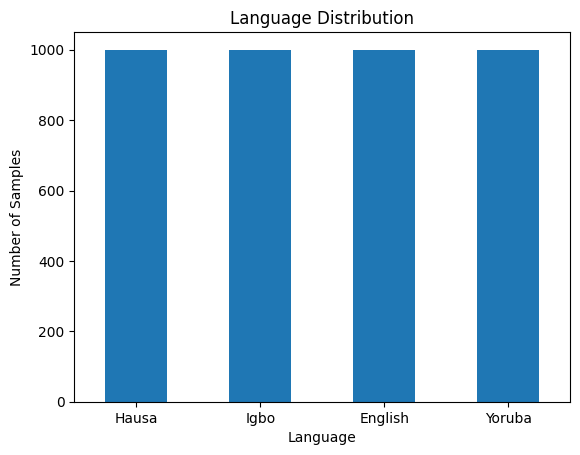

In [ ]:
df["language"].value_counts().plot(kind="bar")

plt.title("Language Distribution")
plt.xlabel("Language")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.show()

## 4. Train-Test Split

The dataset was divided into:

- **80% training data**
- **20% testing data**

Stratified splitting was used to maintain an equal language distribution
between the training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["language"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3200
Testing samples: 800


## 5. Feature Extraction with TF-IDF

Machine learning models cannot directly process raw text, so the text was
converted into numerical features using **TF-IDF**.

Character-level n-grams were used with an n-gram range of 2 to 5.

Character n-grams are useful for language identification because different
languages contain distinctive character sequences and orthographic patterns.

In [ ]:
vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training feature matrix:", X_train_tfidf.shape)
print("Testing feature matrix:", X_test_tfidf.shape)

Training feature matrix: (3200, 14038)
Testing feature matrix: (800, 14038)


## 6. Model Training

A Logistic Regression classifier was trained using the TF-IDF features.

Logistic Regression was selected as a simple, efficient baseline for
multi-class text classification.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Model training complete.")

Model training complete.


In [ ]:
y_pred = model.predict(X_test_tfidf)

print("Predictions complete.")
print(y_pred[:10])

Predictions complete.
['English' 'Hausa' 'English' 'Hausa' 'English' 'Yoruba' 'Igbo' 'Igbo'
 'Hausa' 'English']


## 7. Model Evaluation

The trained model was evaluated using the held-out test set.

The evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 1.0000
Accuracy: 100.00%


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     English       1.00      1.00      1.00       200
       Hausa       1.00      1.00      1.00       200
        Igbo       1.00      1.00      1.00       200
      Yoruba       1.00      1.00      1.00       200

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



## 8. Confusion Matrix

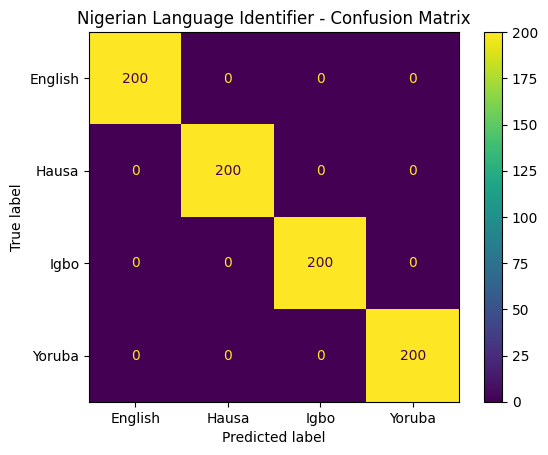

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Nigerian Language Identifier - Confusion Matrix")
plt.show()

### Evaluation Results

The model achieved **100% accuracy** on the 800-sample synthetic test set.

All four language classes achieved:

- Precision: 1.00
- Recall: 1.00
- F1-score: 1.00

The confusion matrix showed no misclassification among the four language
classes in the held-out synthetic test set.

## 9. Manual Testing

Additional phrases that were not part of the formal evaluation were tested
to examine how the model performs on new inputs.

The model correctly classified the initial examples for English, Hausa,
Igbo, and Yoruba.

A short-phrase stress test was also performed. The model correctly classified
7 out of 8 manually supplied phrases, with `Ndewo` being incorrectly
classified as English.

This demonstrates that the perfect held-out test score does not necessarily
represent performance on all real-world text, particularly very short or
unseen expressions.

In [ ]:
test_phrases = [
    "Bawo ni o se wa loni?",
    "Ina kwana? Ya ya gida?",
    "Kedu ka ị mere taa?",
    "How are you doing today?"
]

test_features = vectorizer.transform(test_phrases)
predictions = model.predict(test_features)

for text, prediction in zip(test_phrases, predictions):
    print(f"{text} --> {prediction}")

Bawo ni o se wa loni? --> Yoruba
Ina kwana? Ya ya gida? --> Hausa
Kedu ka ị mere taa? --> Igbo
How are you doing today? --> English


In [ ]:
test_phrases = [
    "Mo wa",
    "Ina kwana",
    "Ndewo",
    "Good morning",
    "Mo fẹ́ jẹun",
    "Ina son ruwa",
    "Achọrọ m nri",
    "Thank you very much"
]

test_features = vectorizer.transform(test_phrases)
predictions = model.predict(test_features)

for text, prediction in zip(test_phrases, predictions):
    print(f"{text} --> {prediction}")

Mo wa --> Yoruba
Ina kwana --> Hausa
Ndewo --> English
Good morning --> English
Mo fẹ́ jẹun --> Yoruba
Ina son ruwa --> Hausa
Achọrọ m nri --> Igbo
Thank you very much --> English


## 10. Interactive Gradio Application

A Gradio interface was created to allow users to enter a short phrase and
receive:

- Predicted language
- Model confidence
- Probability estimates for each supported language

Supported languages:

- English
- Hausa
- Igbo
- Yoruba

In [ ]:
!pip install gradio -q

In [94]:
def predict_language(text):
    features = vectorizer.transform([text])

    probabilities = model.predict_proba(features)[0]
    classes = model.classes_

    results = {
        language: float(probability)
        for language, probability in zip(classes, probabilities)
    }

    prediction = model.predict(features)[0]
    confidence = max(probabilities)

    return prediction, confidence, results

In [95]:
import gradio as gr

demo = gr.Interface(
    fn=predict_language,
    inputs=gr.Textbox(
        label="Enter a phrase",
        placeholder="Type a phrase in English, Hausa, Igbo, or Yoruba..."
    ),
    outputs=[
        gr.Textbox(label="Predicted Language"),
        gr.Number(label="Confidence"),
        gr.Label(label="Language Probabilities")
    ],
    title="🇳🇬 Nigerian Language Identifier",
    description="Identify whether a short phrase is English, Hausa, Igbo, or Yoruba.",
    examples=[
        ["Bawo ni o se wa loni?"],
        ["Ina kwana? Ya ya gida?"],
        ["Kedu ka ị mere taa?"],
        ["How are you doing today?"]
    ]
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c93b6329a6539c3dd.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 11. Saving the Trained Model

The trained Logistic Regression model and TF-IDF vectorizer were saved using
Joblib so they can be loaded and used later without retraining.

In [ ]:
import joblib

In [ ]:
joblib.dump(model, "nigerian_language_model.pkl")

['nigerian_language_model.pkl']

In [ ]:
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [97]:
files.download("nigerian_language_dataset_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Limitations

This project is an MVP and has several limitations.

### Synthetic Dataset

The dataset used for this project was synthetically generated. Therefore,
the 100% test accuracy should not be interpreted as 100% real-world language
identification accuracy.

Synthetic text may contain patterns that are easier for the model to learn
than naturally occurring language.

### Short Text

Very short phrases can be more difficult to classify because they contain
fewer linguistic patterns. During manual testing, the Igbo phrase `Ndewo`
was incorrectly classified as English.

### Language Coverage

The current model supports only four languages:

- English
- Hausa
- Igbo
- Yoruba

Additional Nigerian languages could be added in future versions.

## 13. Future Improvements

Future versions could improve the system by:

- Expanding the dataset with naturally occurring Nigerian-language text
- Adding more Nigerian languages
- Collecting larger and more diverse datasets
- Comparing additional classification algorithms
- Improving performance on very short phrases
- Adding speech/audio language identification
- Deploying the classifier as an API
- Integrating the language identifier into conversational AI systems